# 15. Object-Oriented Programming in Python

**Class.** A class is a template for creating objects. Classes contain the definition of the objects we work with and define their properties (**attributes**) as well as specifying the modifications that can be made to those objects (**methods**).

Every time we construct an object of a class, we are creating an instance of that class.

**Object.** It is an instance of a class and consists of:

- **State.** Represented by the object's attributes, reflecting its properties.
- **Behavior.** Represented by the object's methods, reflecting its response to other objects.
- **Identity.** Each object has a unique name that allows it to interact with other objects.

Classes are fundamental to object-oriented programming languages, such as `Python`.

In essence, a class is a template and an instance is a copy of the class with specific values: an object.

![classes_and_objects](class_objects.png)

Let's create our first class: the `Book` class. Classes are created using the reserved keyword `class`.

For now, our class will consist only of a static variable called `is_electronic`, which will be set to `False`, indicating that all objects of this class will be non-electronic books.

**Static Variable.** These are variables that belong to the class.

In [1]:
class Book():
    is_electronic = False

We have now created our object template `Book`, which only contains whether the book in question is electronic or not.

If we now want to create an object of the `Book` class, we will have to instantiate it as follows:

In [2]:
book1 = Book()

We have constructed an object of the `Book` class with our template, therefore `book1` is a non-electronic book.

Just as we did before, if we want to know which class the `book1` object belongs to, we apply the `type()` function.

In [3]:
type(book1)

__main__.Book

If we now want to access the only variable of the class, `is_electronic`, then we introduce:

In [4]:
Book.is_electronic

False

and thus verify that indeed, the value of the static variable of `Book` is `False`.

Let's improve our `Book` class by adding docstrings.

In [5]:
class Book():
    """
    Class for working with books.
    """

    is_electronic = False

Now we can access that docstring with the `.__doc__` method.

In [6]:
print(Book.__doc__)


    Class for working with books.
    


## 15.1. The Constructor Method

Let's continue improving our class, this time by modifying the `.__init__()` method, which is called when we initialize an object of the class. This is the constructor method. It can receive values for the attributes of each object as parameters:

**Attribute.** These are the variables that define the objects of a class. They are its characteristics.

In [7]:
class Book():
    """
    Class for working with books.
    """

    def __init__(self, title, author, electronic):
        self.title = title
        self.author = author
        self.is_electronic = electronic

We will discuss the `self` parameter later when we talk about instance methods.

Now, if we want to create an object of the `Book` class, given how we have constructed the `.__init__` method, we will need to specify the title and author of the book.

In [8]:
book2 = Book("The Lord of the Rings", "J.R.R. Tolkien", False)

In [9]:
book2.title

'The Lord of the Rings'

In [10]:
book2.author

'J.R.R. Tolkien'

In [11]:
book2.is_electronic

False

To access all the attributes of an object and the values assigned to them, we can use the `.__dict__` method.

In [12]:
book2.__dict__

{'title': 'The Lord of the Rings',
 'author': 'J.R.R. Tolkien',
 'is_electronic': False}

If we want to avoid having to input any of those parameters every time we initialize an object of the `Book` class, remember that we can set default values for those parameters.

In [13]:
class Book():
    """
    Class for working with books.
    """

    def __init__(self, title, author = "", electronic = False):
        self.title = title
        self.author = author
        self.is_electronic = electronic

In [14]:
book3 = Book(title="One Thousand and One Nights")

In [15]:
book3.title

'One Thousand and One Nights'

In [16]:
book3.is_electronic

False

Thus, the only mandatory argument to input is the title. The rest are optional as they have default values.

## 15.2. The Destructor Method

Just as there is a constructor method, there is also a destructor method whose purpose is to delete instances of a class. In other words, it deletes an object.

The destructor method is the `.__del__()` method.

In [17]:
class Book():
    """
    Class for working with books
    """

    def __init__(self, title, author="", electronic=False):
        self.title = title
        self.author = author
        self.is_electronic = electronic

    def __del__(self):
        print("You have just called the destructor method. The object has just been deleted.")

To delete an object, we use the reserved keyword `del` in Markdown code.

In [18]:
book = Book("The Chronicles Of Narnia")
book.title

'The Chronicles Of Narnia'

In [19]:
del book

You have just called the destructor method. The object has just been deleted.


If we tried to access the `book` object, we would get an error because it has ceased to be an instance of the `Book` class since we have deleted it.

## 15.3. Methods of a Class

There are 3 types of methods:

- Instance Methods
- Static Methods
- Class Methods

### 15.3.1. Métodos de instancia

They always take the `self` parameter as the first parameter.

The `self` parameter represents the instance of the method. What `Python` does is pass the object itself as an argument to the method.

In [20]:
class Rectangle():

    def __init__(self, base = 1, height = 1, color = "blue"):
        self.base = base
        self.height = height
        self.color = color

    def perimeter(self):
        return 2 * self.base + 2 * self.height

    def area(self):
        return self.base * self.height

In [21]:
rect1 = Rectangle(5, 2, "red")
print("The perimeter is {}".format(rect1.perimeter()))
print("The area is {}".format(rect1.area()))

The perimeter is 14
The area is 10


If we now modify the base, both the perimeter and the area will also change their value.

In [22]:
rect1.base = 3
print("After changing the value of the base to 3, the perimeter is {}".format(rect1.perimeter()))
print("After changing the value of the base to 3, the area is {}".format(rect1.area()))

After changing the value of the base to 3, the perimeter is 10
After changing the value of the base to 3, the area is 6


Instance methods can have more inputs besides `self`. Let's add a method that returns true if the base is greater than a minimum value, which we will call `min`, and by default, we'll set it to 5.

In [23]:
class Rectangle():

    def __init__(self, base = 1, height = 1, color = "blue"):
        self.base = base
        self.height = height
        self.color = color

    def perimeter(self):
        return 2 * self.base + 2 * self.height

    def area(self):
        return self.base * self.height

    def is_base_big(self, min = 5):
        if self.base > min:
            return True
        return False

In [24]:
rect1 = Rectangle(3, 2, "red") # Since we have modified the class, we need to rebuild the rect1 object
rect1.is_base_big()

False

In [25]:
rect2 = Rectangle(12, 7)
rect2.is_base_big(10) # We increase the minimum value to 10

True

The `.__str__` method is an instance method. It is the method that should be called when the object is represented as a `string`. In other words, what this method returns is what is shown when we `print` the object in question.

In [26]:
class Rectangle():

    def __init__(self, base = 1, height = 1, color = "blue"):
        self.base = base
        self.height = height
        self.color = color

    def perimeter(self):
        return 2 * self.base + 2 * self.height

    def area(self):
        return self.base * self.height

    def is_base_big(self, min = 5):
        if self.base > min:
            return True
        return False

    def __str__(self):
        return ("Base: {}\nHeight: {}".format(self.base, self.height))

So, if we now create an object of the `Rectangle` class and pass that object as a parameter to the `print()` function, we get the following:

In [27]:
rect3 = Rectangle(15, 9, "pink")
print(rect3)

Base: 15
Height: 9


### 15.3.2. Static Methods

Unlike instance methods, static methods do not pass the positional argument `self`.

Static methods are defined using the `@staticmethod` decorator, which is added before defining the respective static method.

Decorators allow us to alter the behavior of functions or classes. They are used to store utilities related to the class.

Let's create a method that tells us whether two rectangles are equal or not.

In [28]:
class Rectangle():

    def __init__(self, base=1, height=1, color="blue"):
        self.base = base
        self.height = height
        self.color = color

    def perimeter(self):
        return 2 * self.base + 2 * self.height

    def area(self):
        return self.base * self.height

    def is_base_big(self, min_value=5):
        if self.base > 5:
            return True
        return False

    def __str__(self):
        return ("Base: {}\nHeight: {}".format(self.base, self.height))

    @staticmethod
    def are_equal_size(rect1, rect2):
        if rect1.base == rect2.base and rect1.height == rect2.height:
            return True
        return False

In [29]:
rect1 = Rectangle(7, 5, "green")
rect2 = Rectangle(3 + 4, 7 - 2, "blue")
print(rect1, "\n")
print(rect2, "\n")
print(Rectangle.are_equal_size(rect1, rect2))

Base: 7
Height: 5 

Base: 7
Height: 5 

True


### 15.3.3. Class Methods

The characteristic of these methods is that the entire class is passed as the first argument, `cls`. For class methods, a decorator, `@classmethod`, is used again.

Let's create a method that generates a rectangle randomly. To do this, we need to import the `random` library.

In [30]:
import random

In [31]:
class Rectangle():

    def __init__(self, base=1, height=1, color="blue"):
        self.base = base
        self.height = height
        self.color = color
  
    def perimeter(self):
        return 2 * self.base + 2 * self.height

    def area(self):
        return self.base * self.height

    def is_base_big(self, min_value=5):
        if self.base > min_value:
            return True
        return False

    def __str__(self):
        return ("Base: {}\nHeight: {}".format(self.base, self.height))

    @staticmethod  
    def are_equal_size(rect1, rect2):
        if rect1.base == rect2.base and rect1.height == rect2.height:
            return True
        return False

    @classmethod
    def random_rectangle(cls):
        base = random.randrange(1, 10)
        height = random.randrange(1, 10)
        return cls(base, height)

In [32]:
rect3 = Rectangle.random_rectangle()
print(rect3)

Base: 1
Height: 5


## 15.4. Propiedades

To handle the attributes of an object, we can use the `@property` decorator, which allows a method to be accessed like an attribute, thus omitting the use of empty parentheses.

**Note:** Parentheses are empty when there are no parameters to indicate in a method.

The `.perimeter()` and `.area()` methods are the perfect example to be modified by the `@property` decorator because whenever they are called, they never take values as parameters.

In [33]:
class Rectangle():

    def __init__(self, base=1, height=1, color="blue"):
        self.base = base
        self.height = height
        self.color = color
  
    @property
    def perimeter(self):
        return 2 * self.base + 2 * self.height

    @property
    def area(self):
        return self.base * self.height

    def is_base_big(self, min_value=5):
        if self.base > min_value:
            return True
        return False

    def __str__(self):
        return ("Base: {}\nHeight: {}".format(self.base, self.height))

    @staticmethod  
    def are_equal_size(rect1, rect2):
        if rect1.base == rect2.base and rect1.height == rect2.height:
            return True
        return False

    @classmethod
    def random_rectangle(cls):
        base = random.randrange(1, 10)
        height = random.randrange(1, 10)
        return cls(base, height)

In [34]:
rect4 = Rectangle(2, 3, "yellow")

In [35]:
rect4.perimeter

10

In [36]:
rect4.area

6

The `@property` decorator only allows us to access the method as if it were an attribute, but that doesn't mean it can be treated as one. If we try to modify it as if it were an attribute, we will get an error.

In [37]:
rect4.perimeter = 12

AttributeError: property 'perimeter' of 'Rectangle' object has no setter

To modify a property, we need to use the `.setter()` method.

Let's see an example:

In [ ]:
class Person():

    def __init__(self, name, surname):
        self.name = name
        self.surname = surname

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, name_surname):
        name, surname = name_surname.split(" ")
        self.name = name
        self.surname = surname

The `Person` class takes parameters for the name and surname of a person. It has a property that returns the full name of that person.

Thanks to the `.setter()` method, we are able to modify this property. We have achieved this using a decorator with the name of the property followed by `.setter`.

To modify the full name, we must input it as a parameter.

In [38]:
person1 = Person("Bob", "Smith")
person1.complete_name

NameError: name 'Person' is not defined

In [39]:
person1.complete_name = "Bob Smith"
person1.surname

NameError: name 'person1' is not defined

Another very common use of the `.setter()` method is to prevent the user from entering values that should not be allowed.

For example, a circle cannot have a diameter that is 0 or less:

In [40]:
class Circle():

    def __init__(self, center=(0, 0), radius=1):
        self.center = center
        self.radius = radius

    @property
    def diameter(self):
        return 2 * self.radius

    @diameter.setter
    def diameter(self, value):
        if value <= 0:
            raise ValueError("The diameter cannot be less than or equal to 0")
        self.radius = value / 2

If we now try to modify the diameter to a value that is 0 or negative, we will get the `ValueError` that we have configured previously.

In [41]:
circle1 = Circle(radius = 2)
circle1.diameter = -2

ValueError: The diameter cannot be less than or equal to 0

## 15.5. Class `inheritance`

This class allows attributes and methods to be passed from one class to another. It is useful when there is already a class that does everything we need, to which we would like to add some extra attribute or method.

Suppose we want to create two classes: one representing children (people under 18) and another representing adults.

The `Children` class would be:

In [42]:
class Children():

    is_adult = False

    def __init__(self, name, surname, age):
        self.name = name
        self.surname = surname
        self.age = age

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, name_surname):
        name, surname = name_surname.split(" ")
        self.name = name
        self.surname = surname

And the `Adult` class would be:

In [43]:
class Adult():

    is_adult = True

    def __init__(self, name, surname, age):
        self.name = name
        self.surname = surname
        self.age = age

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, name_surname):
        name, surname = name_surname.split(" ")
        self.name = name
        self.surname = surname

We are repeating a lot of code. To be exact, the only difference between both classes is the `.is_adult` attribute, which is `False` in `Children` and `True` in `Adult`.

### 15.5.1. Single Inheritance

It involves creating child classes that inherit attributes and methods from a single parent class. Taking the two previous classes, `Children` and `Adult`, we have the `Person` class that represents the common parts of the `Children` and `Adult` classes.

In [44]:
class Person(object):

    def __init__(self, name, surname, age):
        self.name = name
        self.surname = surname
        self.age = age

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, name_surname):
        name, surname = name_surname.split(" ")
        self.name = name
        self.surname = surname

So now the `Children` and `Adult` classes can be created as children of the parent class `Person`.

In [45]:
class Children(Person):
    is_adult = False

In [46]:
class Adult(Person):
    is_adult = True

In [47]:
child = Children("Bob", "Smith", 6)
child.name

'Bob'

This way, the logic of the `.__init__()` is specified only once, making it much easier to modify it in the future from the parent class. Similarly, it will also be easier to create different subclasses of the `Person` class. Additionally, it is also possible to create subclasses of the subclass `Children`, such as `Teenager`, depending on the age range within the interval [0, 18).

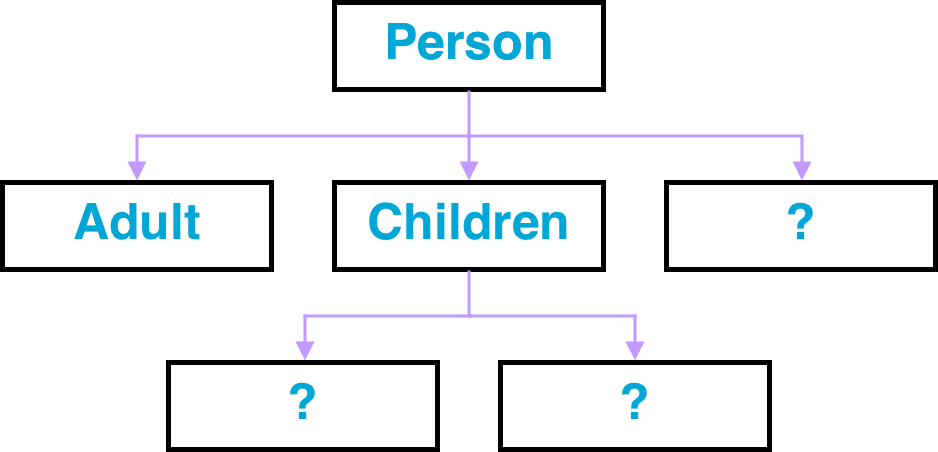

Just as we have inherited from the class we created, `Person`, we can inherit from an existing class in Python, such as the `int` class.

In [48]:
class MyInt(int):
    def is_divisible_by(self, divisor):
        return self % divisor == 0

In [49]:
n = MyInt(27)
n.is_divisible_by(9)

True

### 15.5.2. Overriding Methods

With class inheritance, we can not only extend the behavior of more general classes, but we can also modify some inherited attributes or methods from the parent class.

Let's suppose we have the `Person()` class:

In [50]:
class Person(object):

    def __init__(self, name, surname, age):
        self.name = name
        self.surname = surname
        self.age = age

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, name_surname):
        name, surname = name_surname.split(" ")
        self.name = name
        self.surname = surname

But when entering the full name, we have problems because the person has a middle name. So we could create a `SecondNamePerson` class that takes these aspects into account regarding the full name.

In [51]:
class SecondNamePerson(Person):

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, names_surname):
        names = names_surname.split(" ")
        self.surname = names[-1]
        if len(names) > 2:
            self.name = " ".join(names[:(len(names)-1)])
        elif len(names) == 2:
            self.name = names[0]

In [52]:
person2 = SecondNamePerson("Bob", "Smith", 32)
person2.complete_name = "Bob John Smith"
print(person2.name)
print(person2.surname)

Bob John
Smith


The `.super()` method is used to access a method from the parent class.

In [53]:
class Person(object):

    def __init__(self, name, surname, age):
        self.name = name
        self.surname = surname
        self.age = age

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, name_surname):
        name, surname = name_surname.split(" ")
        self.name = name
        self.surname = surname
      
    @property
    def introduction(self):
        print("Hello, my name is {}".format(self.complete_name))

Let's suppose we want to create a subclass so that a person can say many more things when introducing themselves:

In [54]:
class TalkativePerson(Person):

    @property
    def introduction(self):
        print("Hello, my name is {}".format(self.complete_name))
        print("Nice to meet you!")

In [55]:
person3 = TalkativePerson("Bob", "Smith", 16)
person3.introduction

Hello, my name is Bob Smith
Nice to meet you!


What we did before is correct, although we are copying the first sentence as it is from the `Person` class. To avoid this duplication, we can use the `.super()` method.

In [56]:
class TalkativePerson(Person):

    @property
    def introduction(self):
        super().introduction
        print("Nice to meet you!")

In [57]:
person4 = TalkativePerson("Bob", "Smith", 16)
person4.introduction

Hello, my name is Bob Smith
Nice to meet you!


### 15.5.3. Multiple Inheritance

It involves creating child classes that inherit attributes and methods from multiple parent classes.

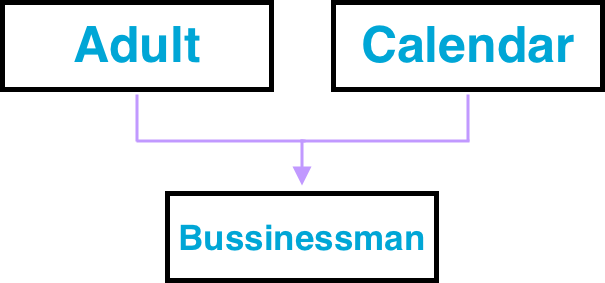


In this case, in addition to the `Adult` class, which inherits from the `Person` class, we are going to have the `Calendar` class.

In [58]:
class Person(object):

    def __init__(self, name, surname, age):
        self.name = name
        self.surname = surname
        self.age = age

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, name_surname):
        name, surname = name_surname.split(" ")
        self.name = name
        self.surname = surname
      
    @property
    def introduction(self):
        print("Hello, my name is {}".format(self.complete_name))

class Adult(Person):
    is_adult = True

In [59]:
class Calendar(object):

    @staticmethod
    def new_event(title, day, hour, duration="All day"):
        print("Reserved for {} on {} at {} for {}.".format(title, day, hour, duration))

Finally, let's create a subclass that inherits from both `Adult` and `Calendar`, which we will call `Businessman`. This subclass will not have any additional methods or arguments, so we will use the `pass` statement.

In [60]:
class Bussinessman(Adult, Calendar):
    pass

In [61]:
bussinessman = Bussinessman("Bob", "Alice", 38)
bussinessman.introduction
Bussinessman.new_event("Meet", "30 de Septiembre", "16:30", "2 hours")

Hello, my name is Bob Alice
Reserved for Meet on 30 de Septiembre at 16:30 for 2 hours.


Now that we inherit from more than one parent class, what happens when we use the `.super()` method?

If none of the parent classes have any methods with the same name, then there is no problem. However, if we find ourselves in the opposite case, where there are one or more methods with the same name in both classes, then the method that will be used when calling it with the `.super()` method is the one belonging to the first parent class from which it is inherited.

Let's see it with an example: we have the class `ClassAB` that will inherit from the classes `ClassA` and `ClassB`

In [62]:
class ClassA():

    def say_letter(self):
        print("My letter is A")
        
class ClassB():

    def say_letter(self):
        print("My letter is B")

In [63]:
class ClassAB(ClassA, ClassB):

     def my_letter(self):
         print("Even though I inherit the letters A and B (as indicated by my name)")
         super().say_letter()

In [64]:
ab = ClassAB()
ab.my_letter()

Even though I inherit the letters A and B (as indicated by my name)
My letter is A


In [65]:
class ClassAB(ClassB, ClassA):

    def my_letter(self):
        print("Even though I inherit the letters A and B (as indicated by my name)")
        super().say_letter()

In [66]:
ab = ClassAB()
ab.my_letter()

Even though I inherit the letters A and B (as indicated by my name)
My letter is B


**Note.** This not only happens when we use the `.super()` method, but also when we want to access a method whose name is present in more than one parent class.

In [67]:
class ClassAB(ClassA, ClassB):
    pass

In [68]:
ab = ClassAB()
ab.say_letter()

My letter is A


In [69]:
class ClassAB(ClassB, ClassA):
    pass

In [70]:
ab = ClassAB()
ab.say_letter()

My letter is B


## 15.6. Polymorphism

**Polymorphism.** It means that a function with the same name is used for different types of objects.

A perfect example is the `len()` function that works for both `string` type objects and lists.

In [71]:
print(len("math")) # Applied to string
print(len([1, 2, 3])) # Applied to list

4
3


In object-oriented programming we also find functions that have the same name, but can be applied to different objects.

In [72]:
class Spain():
    def capital(self):
        print("Madrid is the capital of Spain")
  
    def language(self):
        print("Spanish is spoken in Spain")

  
class Portugal():
    def capital(self):
        print("Lisbon is the capital of Portugal.")
  
    def language(self):
        print("Portuguese is spoken in Portugal")

spain = Spain()
portugal = Portugal()
for country in (spain, portugal):
    country.capital()
    country.language()
    print("")

Madrid is the capital of Spain
Spanish is spoken in Spain

Lisbon is the capital of Portugal.
Portuguese is spoken in Portugal



Even when we talk about inheritance, we can also find polymorphisms as we saw for example with the classes `Person` and `SecondNamePerson`, where both shared the `.complete_name()` method

In [73]:
class Person():

    def __init__(self, name, surname, age):
        self.name = name
        self.surname = surname
        self.age = age

    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, name_surname):
        name, surname = name_surname.split(" ")
        self.name = name
        self.surname = surname

In [74]:
class SecondNamePerson(Person):
    @property
    def complete_name(self):
        return "{} {}".format(self.name, self.surname)

    @complete_name.setter
    def complete_name(self, names_surname):
        names = names_surname.split(" ")
        self.surname = names[-1]
        if len(names) > 2:
            self.name = " ".join(names[:(len(names)-1)])
        elif len(names) == 2:
            self.name = names[0]

In [75]:
person2 = SecondNamePerson("Bob", "Smith", 32)
person2.complete_name = "Bob John Smith"
print(person2.name)
print(person2.surname)

Bob John
Smith


## 15.7. Problems

### 15.7.1. Problem 1

Create the `RationalNumber` class. Configure the constructor so that there is a `numerator` attribute and another `denominator` attribute, the latter with 1 as the default value. Both attributes must be integers.

In [76]:
class RationalNumber():

    def __init__(self, n, d = 1):
        if type(n) is int and type(d) is int:
            self.numerator = n
            self.denominator = d
        else:
            print("The numerator and denominator must be integers")

### 15.7.2. Problem 2

Configure the method in problem 1 `.__str__()` to display the rational number of the numerator/denominator form.

**EXTRA**: Find how to use LaTeX in Python strings and build the `.mathMode()` method that displays the rational number in $\frac{\text{numerator}}{\text{denominator}}$ format.

In [77]:
class RationalNumber():

    def __init__(self, n, d = 1):
        if type(n) is int and type(d) is int:
            self.numerator = n
            self.denominator = d
        else:
            print("The numerator and denominator must be integers")

    
    def __str__(self):
        return "{} / {}".format(self.numerator, self.denominator)

  
    def mathFormat(self):
        from IPython.display import display, Latex # This only works in the IPython kernel
        display(Latex(f"${self.numerator}\\over{self.denominator}$"))

In [78]:
q = RationalNumber(2, 4)
print(q)

2 / 4


In [79]:
q.mathFormat()

<IPython.core.display.Latex object>

### 15.7.3. Problem 3

Implement the `.quotient()` instance method that returns the quotient. Implement the `.isInfinite()` instance method that returns whether the denominator is 0 or not. Implement the `.simplify()` instance method that simplifies the fraction to the irreducible fraction.

In [80]:
def bigger(a, b): 
    """
    Returns the greater of two real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a >= b: 
        return a
    return b

def lower(a, b): 
    """
    Returns the smaller of two real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a <= b: 
        return a
    return b

def gcd(a, b): 
    """
    Returns the GCD of two integers.
    Args:
        a: Integer
        b: Integer
    Returns:
        max: Integer
    """
    r=0
    max_val = bigger(a, b) 
    min_val = lower(a, b)
    while(min_val > 0):
        r = min_val
        min_val = max_val % min_val 
        max_val = r
    return max_val


class RationalNumber():

    def __init__(self, n, d = 1):
        if type(n) is int and type(d) is int:
            self.numerator = n
            self.denominator = d
        else:
            print("The numerator and the denominator must be integers")

    
    def __str__(self):
        return "{} / {}".format(self.numerator, self.denominator)

  
    def mathFormat(self):
        from IPython.display import display, Latex
        display(Latex(f"${self.numerator}\\over{self.denominator}$"))


    def quotient(self):
        return self.numerator / self.denominator

  
    def isInfinite(self):
        if self.denominator == 0:
            return True
        return False


    def simplify(self):
        div = gcd(self.numerator, self.denominator)
        self.numerator = int(self.numerator / div)
        self.denominator = int(self.denominator / div)

In [81]:
q = RationalNumber(2, 4)

In [82]:
q.mathFormat()

<IPython.core.display.Latex object>

In [83]:
q.quotient()

0.5

In [84]:
q.isInfinite()

False

In [85]:
q.simplify()

In [86]:
q.mathFormat()

<IPython.core.display.Latex object>

In [87]:
p = RationalNumber(3, 4)

In [88]:
p.simplify()
p.mathFormat()

<IPython.core.display.Latex object>

### 15.7.4. Problem 4

Implement the following static methods:

- `.sum()` dode $\displaystyle\frac{p_1}{q_1} + \frac{p_2}{q_2} = \frac{p_1q_2 + p_2q_1}{q_1 \cdot q_2}$
- `.subract()` dode $\displaystyle\frac{p_1}{q_1} - \frac{p_2}{q_2} = \frac{p_1q_2 - p_2q_1}{q_1 \cdot q_2}$
- `.product()` where $\displaystyle\frac{p_1}{q_1} \cdot \frac{p_2}{q_2} = \frac{p_1 \cdot p_2}{q_1 \cdot q_2}$
- `.division()` where $\displaystyle\frac{p_1}{q_1} \div \frac{p_2}{q_2} = \frac{p_1 \cdot q_2}{p_2 \cdot q_1}$

In [89]:
def bigger(a, b): 
    """
    Returns the greater of two real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a >= b: 
        return a
    return b

def lower(a, b): 
    """
    Returns the smaller of two real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a <= b: 
        return a
    return b

def gcd(a, b): 
    """
    Returns the GCD of two integers.
    Args:
        a: Integer
        b: Integer
    Returns:
        max: Integer
    """
    r=0
    max_val = bigger(a, b) 
    min_val = lower(a, b)
    while(min_val > 0):
        r = min_val
        min_val = max_val % min_val 
        max_val = r
    return max_val

def helper(n, d):
    print("{} / {} = {}".format(n, d, n / d))


class RationalNumber():

    def __init__(self, n, d = 1):
        if type(n) is int and type(d) is int:
            self.numerator = n
            self.denominator = d
        else:
            print("The numerator and denominator must be integers")

    
    def __str__(self):
        return "{} / {}".format(self.numerator, self.denominator)

  
    def mathFormat(self):
        from IPython.display import display, Latex
        display(Latex(f"${self.numerator}\\over{self.denominator}$"))


    def quotient(self):
        return self.numerator / self.denominator

  
    def isInfinite(self):
        if self.denominator == 0:
            return True
        return False


    def simplify(self):
        div = gcd(self.numerator, self.denominator)
        self.numerator = int(self.numerator / div)
        self.denominator = int(self.denominator / div)


    @staticmethod
    def sum(p, q):
        num = p.numerator * q.denominator + q.numerator * p.denominator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def subtract(p, q):
        num = p.numerator * q.denominator - q.numerator * p.denominator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def product(p, q):
        num = p.numerator * q.numerator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def division(p, q):
        num = p.numerator * q.denominator
        den = p.denominator * q.numerator
        helper(num, den)

In [90]:
p = RationalNumber(1, 2)
q = RationalNumber(2, 3)
RationalNumber.division(p, q)

3 / 4 = 0.75


### 15.7.5. Problem 5

Configure the following class methods:

- `.random()` which is responsible for creating a random object of the `RationalNumber` class.
- `.zero()` which is responsible for creating the object of the `RationalNumber` class that has a numerator of 0 and a denominator of 1.
- `.one()` which is responsible for creating the object of the `RationalNumber` class that has a numerator of 1 and a denominator of 1.
- `.fromRealNumber()` which, given a real number, is responsible for searching for its rational expression. For example, given 5.4, we will need to create the `RationalNumber` object with numerator 54 and denominator 10. Investigate the `math.modf()` method for this case.

In [91]:
def bigger(a, b): 
    """
    Returns the greater of two real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a >= b: 
        return a
    return b

def lower(a, b): 
    """
    Returns the smaller of two real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a <= b: 
        return a
    return b

def gcd(a, b): 
    """
    Returns the GCD of two integers.
    Args:
        a: Integer
        b: Integer
    Returns:
        max: Integer
    """
    r = 0
    max_val = bigger(abs(a), abs(b)) 
    min_val = lower(abs(a), abs(b))
    while min_val > 0:
        r = min_val
        min_val = max_val % min_val 
        max_val = r
    return max_val

def helper(n, d):
    print("{} / {} = {}".format(n, d, n / d))


class RationalNumber():

    def __init__(self, n, d=1):
        if type(n) is int and type(d) is int:
            self.numerator = n
            self.denominator = d
        else:
            print("The numerator and denominator must be integers")

    
    def __str__(self):
        return "{} / {}".format(self.numerator, self.denominator)

  
    def mathFormat(self):
        from IPython.display import display, Latex
        display(Latex(f"${self.numerator}\\over{self.denominator}$"))


    def quotient(self):
        return self.numerator / self.denominator

  
    def isInfinite(self):
        if self.denominator == 0:
            return True
        return False


    def simplify(self):
        div = gcd(self.numerator, self.denominator)
        self.numerator = int(self.numerator / div)
        self.denominator = int(self.denominator / div)


    @staticmethod
    def sum(p, q):
        num = p.numerator * q.denominator + q.numerator * p.denominator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def subtract(p, q):
        num = p.numerator * q.denominator - q.numerator * p.denominator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def product(p, q):
        num = p.numerator * q.numerator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def division(p, q):
        num = p.numerator * q.denominator
        den = p.denominator * q.numerator
        helper(num, den)


    @classmethod
    def random(cls):
        import random
        num = random.randrange(-100, 100)
        den = random.randrange(-100, 100)
        while den == 0:
            den = random.randrange(-100, 100)
        return cls(num, den)

  
    @classmethod
    def zero(cls):
        return cls(0)


    @classmethod
    def one(cls):
        return cls(1)


    @classmethod
    def fromRealNumber(cls, f):
        import math
        num = f
        den = 1
        d, i = math.modf(num)
        while d != 0:
            num *= 10
            den *= 10
            d, i = math.modf(num)
        num = int(num)
        den = int(den)
        return cls(num, den)

In [92]:
p = RationalNumber.random()
p.mathFormat()

<IPython.core.display.Latex object>

In [93]:
p.simplify()
p.mathFormat()

<IPython.core.display.Latex object>

In [94]:
zero = RationalNumber.zero()
zero.mathFormat()

<IPython.core.display.Latex object>

In [95]:
one = RationalNumber.one()
one.mathFormat()

<IPython.core.display.Latex object>

In [96]:
q = RationalNumber.fromRealNumber(0.72)

In [97]:
q.mathFormat()

<IPython.core.display.Latex object>

### 15.7.6. Problem 6

Convert the `.quotient()` and `.mathFormat()` methods to a property.

In [98]:
def bigger(a, b): 
    """
    Returns the larger of two given real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a >= b: 
        return a
    return b

def lower(a, b): 
    """
    Returns the smaller of two given real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a <= b: 
        return a
    return b

def gcd(a, b): 
    """
    Returns the greatest common divisor (GCD) of two integers.
    Args:
        a: Integer
        b: Integer
    Returns:
        max: Integer
    """
    r = 0
    max_val = bigger(abs(a), abs(b)) 
    min_val = lower(abs(a), abs(b))
    while min_val > 0:
        r = min_val
        min_val = max_val % min_val 
        max_val = r
    return max_val

def helper(n, d):
    print("{} / {} = {}".format(n, d, n / d))


class RationalNumber():

    def __init__(self, n, d=1):
        if type(n) is int and type(d) is int:
            self.numerator = n
            self.denominator = d
        else:
            print("The numerator and the denominator must be integers")

    
    def __str__(self):
        return "{} / {}".format(self.numerator, self.denominator)

  
    def mathFormat(self):
        from IPython.display import display, Latex
        display(Latex(f"${self.numerator}\\over{self.denominator}$"))


    def quotient(self):
        return self.numerator / self.denominator

  
    def isInfinite(self):
        if self.denominator == 0:
            return True
        return False


    def simplify(self):
        div = gcd(self.numerator, self.denominator)
        self.numerator = int(self.numerator / div)
        self.denominator = int(self.denominator / div)


    @staticmethod
    def sum(p, q):
        num = p.numerator * q.denominator + q.numerator * p.denominator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def subtract(p, q):
        num = p.numerator * q.denominator - q.numerator * p.denominator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def product(p, q):
        num = p.numerator * q.numerator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def division(p, q):
        num = p.numerator * q.denominator
        den = p.denominator * q.numerator
        helper(num, den)

In [99]:
p = RationalNumber(1, 2)
q = RationalNumber(2, 3)
RationalNumber.division(p, q)

3 / 4 = 0.75


In [100]:
def bigger(a, b): 
    """
    Returns the larger of two given real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a >= b: 
        return a
    return b

def lower(a, b): 
    """
    Returns the smaller of two given real numbers.
    Args:
        a: Real number
        b: Real number
    Returns:
        Real number
    """
    if a <= b: 
        return a
    return b

def gcd(a, b): 
    """
    Returns the greatest common divisor (GCD) of two integers.
    Args:
        a: Integer
        b: Integer
    Returns:
        max: Integer
    """
    r = 0
    max_val = bigger(abs(a), abs(b)) 
    min_val = lower(abs(a), abs(b))
    while min_val > 0:
        r = min_val
        min_val = max_val % min_val 
        max_val = r
    return max_val

def helper(n, d):
    print("{} / {} = {}".format(n, d, n / d))


class RationalNumber():

    def __init__(self, n, d=1):
        if type(n) is int and type(d) is int:
            self.numerator = n
            self.denominator = d
        else:
            print("The numerator and the denominator must be integers")


    def __str__(self):
        return "{} / {}".format(self.numerator, self.denominator)

  
    @property
    def mathFormat(self):
        from IPython.display import display, Latex
        display(Latex(f"${self.numerator}\\over{self.denominator}$"))

    @property
    def quotient(self):
        return self.numerator / self.denominator

  
    def isInfinite(self):
        if self.denominator == 0:
            return True
        return False


    def simplify(self):
        div = gcd(self.numerator, self.denominator)
        self.numerator = int(self.numerator / div)
        self.denominator = int(self.denominator / div)


    @staticmethod
    def sum(p, q):
        num = p.numerator * q.denominator + q.numerator * p.denominator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def subtract(p, q):
        num = p.numerator * q.denominator - q.numerator * p.denominator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def product(p, q):
        num = p.numerator * q.numerator
        den = p.denominator * q.denominator
        helper(num, den)


    @staticmethod
    def division(p, q):
        num = p.numerator * q.denominator
        den = p.denominator * q.numerator
        helper(num, den)


    @classmethod
    def random(cls):
        import random
        num = random.randrange(-100, 100)
        den = random.randrange(-100, 100)
        while den == 0:
            den = random.randrange(-100, 100)
        return cls(num, den)

  
    @classmethod
    def zero(cls):
        return cls(0)


    @classmethod
    def one(cls):
        return cls(1)


    @classmethod
    def fromRealNumber(cls, f):
        import math
        num = f
        den = 1
        d, i = math.modf(num)
        while d != 0:
            num *= 10
            den *= 10
            d, i = math.modf(num)
        num = int(num)
        den = int(den)
        return cls(num, den)

In [101]:
q = RationalNumber.random()

In [102]:
q.mathFormat

<IPython.core.display.Latex object>

In [103]:
q.quotient

-0.5714285714285714

### 15.7.7. Problem 7

Given the class `Point2D`, create the class `Point3D` that inherits from `Point2D`. Modify all methods and use the `.super()` method where necessary to be able to use them with 3-dimensional points.

In [104]:
class Point2D():
  
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        return "({}, {})".format(self.x, self.y)

    @classmethod
    def zero(cls):
        return cls(0, 0)

In [105]:
class Point3D(Point2D):

    def __init__(self, x, y, z):
        super().__init__(x, y)
        self.z = z

    def __str__(self):
        return super().__str__()[:-1] + ", {})".format(self.z)

    @classmethod
    def zero(cls):
        return cls(0, 0, 0)

In [106]:
p = Point2D(1, -1)

In [107]:
print(p)

(1, -1)


In [108]:
cero2D = Point2D.zero()
print(cero2D)

(0, 0)


In [109]:
q = Point3D(1, 2, 3)
print(q)

(1, 2, 3)


In [110]:
cero3D = Point3D.zero()
print(cero3D)

(0, 0, 0)


### 15.7.8. Problem 8

Given the classes `Triangle` and `Square`, create the class `Pyramid` that inherits from the previous two. Practice multiple inheritance. Implement the constructor, the `.area()` method and the `.volume()}` method using the `.super()` method where necessary to be able to build a regular pyramid with square base and correctly calculate the area and volume.

In [111]:
class Square():
    def __init__(self, base):
        self.base = base

    @property
    def perimeter(self):
        return 4 * self.base

    @property
    def area(self):
        return self.base * self.base

class Triangle():
    def __init__(self, base, height):
        self.base = base
        self.height = height
  
    @property
    def area(self):
        return 0.5 * self.base * self.height

In [112]:
import math

class Pyramid(Square, Triangle):
    def __init__(self, base, height):
        super().__init__(base)
        # Pyramid height
        self.height = height

    @property
    def slant_height(self):
        return math.sqrt((self.base / 2) ** 2 + self.height ** 2)

    @property
    def area(self):
        base_area = super().area 
        base_perimeter = super().perimeter
        lateral_area = 0.5 * base_perimeter * self.slant_height
        return lateral_area + base_area

    @property
    def volume(self):
        base_area = super().area 
        return base_area * self.height / 3

In [113]:
p = Pyramid(2, 2)

In [114]:
p.area

12.94427190999916

In [115]:
p.volume

2.6666666666666665

### 15.7.9. Problem 9

Define a class called `Student` , with the attributes `sid` (student id), `name`, `gender`, `type` in the `init` method and a method called `say_name` to print the student's name. All attributes will be passed except `type`, which will have a value like "learning".

In [116]:
class Student():
    
    def __init__(self, sid, name, gender):
        self.sid = sid
        self.name = name
        self.gender = gender
        self.type = "learning"
        
    def say_name(self):
        print("My name is " + self.name)

### 15.7.10. Problem 10

Add the `report` method in the class of problem 9 that prints not only the student name, but also the student id. The method will have another parameter, `score`, which will be passed in a number between 0 and 100 as part of the report.

In [117]:
class Student():
    
    def __init__(self, sid, name, gender):
        self.sid = sid
        self.name = name
        self.gender = gender
        self.type = "learning"
        
    def say_name(self):
        print("My name is " + self.name)
        
    def report(self, score):
        self.say_name()
        print("My id is: " + self.sid)
        print("My score is: " + str(score))

### 15.7.11. Problem 11

Create two objects `("001", "Susan", "F")` and `("002", "Mike", "M")` and call the `say_name` method of the created class of the problem 133. Call the `report` method for student1 and student2 with scores of 95 and 90, respectively. Note that we don't need "self" as an argument here.

In [118]:
student1 = Student("001", "Susan", "F")
student2 = Student("002", "Mike", "M")\

student1.say_name()
student2.say_name()
print(student1.type)
print(student1.gender)

My name is Susan
My name is Mike
learning
F


In [119]:
student1.report(95)
student2.report(90)

My name is Susan
My id is: 001
My score is: 95
My name is Mike
My id is: 002
My score is: 90


### 15.7.12. Problem 12

Modify the class `Student` from problem 8 to add a class attribute `n`, which will record how many objects we are creating. Additionally, add a `num_instances` method to print the number.

In [120]:
class Student():
    
    n = 0

    def __init__(self, sid, name, gender):
        self.sid = sid
        self.name = name
        self.gender = gender
        self.type = "learning"
        Student.n += 1
        
    def say_name(self):
        print("My name is " + self.name)
        
    def report(self, score):
        self.say_name()
        print("My id is: " + self.sid)
        print("My score is: " + str(score))
        
    def num_instances(self):
        print(f"We have {Student.n}-instance in total")

In [121]:
student1 = Student("001", "Susan", "F")
student1.num_instances()
student2 = Student("002", "Mike", "M")
student1.num_instances()
student2.num_instances()

We have 1-instance in total
We have 2-instance in total
We have 2-instance in total


### 15.7.13. Problem 13

Define a class called `Sensor` with the attributes `name`, `location` and `record_date` passed from the creation of an object and a `data` attribute as an empty dictionary to store data. Create a `add_data` method with `t` and `data` as input parameters to include the timestamp and data arrays. Inside this method, assign `t` and `data` to the data attribute with "time" and "data" as keys. Additionally, create a `clear_data` method to clear the data. Create a sensor object.

In [122]:
class Sensor():
    def __init__(self, name, location, record_date):
        self.name = name
        self.location = location
        self.record_date = record_date
        self.data = {}
        
    def add_data(self, t, data):
        self.data["time"] = t
        self.data["data"] = data
        print(f"We have {len(data)} points saved")
        
    def clear_data(self):
        self.data = {}
        print("Data cleared!")

In [123]:
import numpy as np

sensor1 = Sensor("sensor1", "Berkeley", "2019-01-01")
data = np.random.randint(-10, 10, 10)
sensor1.add_data(np.arange(10), data)
sensor1.data

We have 10 points saved


{'time': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 'data': array([  8,   6,   7, -10,  -2,  -3,  -5,  -5,   0,   5])}

### 15.7.14. Problem 14

Create a class `UCBAcc` (a specific type of accelerometer that was created at UC Berkeley) that inherits from `Accelerometer`}
```
class Accelerometer(Sensor):

    def show_type(self):
        print("I am an accelerometer!")
```

but override the `show_type` method that also prints the sensor name.

In [124]:
class Accelerometer(Sensor):
    
    def show_type(self):
        print("I am an accelerometer!")

In [125]:
acc = Accelerometer("acc1", "Oakland", "2019-02-01")
acc.show_type()
data = np.random.randint(-10, 10, 10)
acc.add_data(np.arange(10), data)
acc.data

I am an accelerometer!
We have 10 points saved


{'time': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 'data': array([-7, -7,  4, -9, -9,  5, -7, -1, -5, -5])}

In [126]:
class UCBAcc(Accelerometer):
    
    def show_type(self):
        print(f"I am {self.name}, created at Berkeley!")

In [127]:
acc2 = UCBAcc("UCBAcc", "Berkeley", "2019-03-01")
acc2.show_type()

I am UCBAcc, created at Berkeley!


### 15.7.15. Problem 15

Create a class **NewSensor** that inherits from the `Sensor` class, but updates the attributes by adding a new attribute flag. Using the `super` method, we can avoid referring to the parent class explicitly.

In [128]:
class NewSensor(Sensor):
    def __init__(self,name,location,record_date,brand):
        self.name = name
        self.location = location
        self.record_date = record_date
        self.brand = brand
        self.data = {}

In [129]:
new_sensor = NewSensor("OK", "SF", "2019-03-01", "XYZ")
new_sensor.brand

'XYZ'

In [130]:
class NewSensor(Sensor):
    def __init__(self,name,location,record_date,brand):
        super().__init__(name, location, record_date)
        self.brand = brand

In [131]:
new_sensor = NewSensor("OK", "SF", "2019-03-01", "XYZ")
new_sensor.brand

'XYZ'

### 15.7.16. Problem 16

Create a script called `oop_problem15.py` and in \'it create the class `RegularPolygon`.

- The constructor will take 2 parameters:

$\checkmark$ `base`: length of the base

$\checkmark$ `n`: number of sides

- The `.__str__()` method will display "I am a polygon of {} sides of length {}".
- The `.apothem()` instance method will calculate the apothem. We will turn it into a property.
- The `.area()` instance method will calculate the area of the polygon. We will turn it into a property.
- The `.perimeter()` instance method will calculate the perimeter of the polygon. We will turn it into a property.

- Create the `Triangle`, `Square` and `Pentagon` classes, which inherit from the `RegularPolygon` class. Just change the constructor.

- Create the `Tetrahedron` and `Cube` classes. The first inherits from the `Triangle` class and the second from the `Square` class. We are going to add the `.volume()` method to both classes, which we will convert to a property in both cases. We will also have to slightly modify the `.area` property and the `.__str__()` method.

- We are going to create the class `Circle` that takes the radius `r` as a parameter and has 4 methods: the constructor and the properties `.diameter()`, `.perimeter()` and `. area()`.

- Finally create the `Cylinder` class that inherits from `Circle` and `Square`. Modify the `.area()` property and create the `.volume()` property.

In [132]:
%cd "C:/Users/RJKANG/Desktop/quant/Statistical Learning/Introduction to Statistical Learning"

C:\Users\RJKANG\Desktop\quant\Statistical Learning\Introduction to Statistical Learning


In [133]:
from oop_problem15 import *

In [134]:
s = RegularPolygon(2, 4)
print(s)

I am a polygon of 4 sides of length 2


In [135]:
square = Square(2)
print(square)

I am a polygon of 4 sides of length 2


In [136]:
print(s.perimeter)
print(square.perimeter)

8
8


In [137]:
print(s.area)
print(square.area)

4.000000000000001
4.000000000000001


In [138]:
cube = Cube(2)
print(cube)

I am a polygon of 4 sides of length 2


In [139]:
print(cube.area)

4.000000000000001


In [140]:
print(cube.volume)

8


In [141]:
c = Cylinder(1, 2)

In [142]:
print(c.diameter)

2


In [143]:
print(c.area)

18.84955592153876
